# MLP Grid Search com Validação Cruzada Estratificada

Modelo MLP com PyTorch para previsão de churn de clientes de telecomunicações.
- Grid search com 3 variações de cada hiperparâmetro
- Validação cruzada estratificada (StratifiedKFold)
- Loss function: CrossEntropyLoss
- Métricas: AUC-ROC, PR-AUC, F1, Recall, Precision

## 1. Import Required Libraries

In [1]:
import sys, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    auc,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import warnings

sys.path.insert(0, os.path.abspath('..'))
from src.features.pipeline import (
    build_pipeline,
    save_pipeline as save_feature_pipeline,
)

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

Using device: cpu


## 2. Load Processed Data

In [2]:
# Load processed dataset
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')

print(f'Dataset shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')
print(f'\nDistribuição do target:')
print(df['Churn'].value_counts())

# X permanece como DataFrame — build_pipeline() espera DataFrame
# (OneHotEncoder, OrdinalEncoder e StandardScaler estão dentro do pipeline)
y = df['Churn'].astype(int).values
X = df.drop(columns=['Churn'])

# Determina dimensão de entrada após o pipeline
_tmp_pipeline = build_pipeline()
INPUT_DIM = _tmp_pipeline.fit_transform(X).shape[1]
del _tmp_pipeline

print(f'\nX shape (raw): {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features após pipeline (com OHE): {INPUT_DIM}')

Dataset shape: (7043, 20)
Colunas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Distribuição do target:
Churn
0    5174
1    1869
Name: count, dtype: int64
2026-04-27 17:36:08 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(7043, 15)

X shape (raw): (7043, 19)
y shape: (7043,)
Features após pipeline (com OHE): 30


## 3. Define Hyperparameter Grid

Variações reduzidas para execução mais rápida:
- **batch_size**: 32, 64, 128 (3 opções)
- **activation**: ReLU (1 opção)
- **dropout**: 0.2, 0.3, 0.4 (3 opções)
- **hidden_layers**: 1, 2 (2 opções)
- **hidden_dim**: 32, 64 (2 opções - neurônios nas camadas ocultas)
- **epochs**: 75, 100 (2 opções)
- **learning_rate**: 1e-3 (1 opção fixado)
- **early_stopping_patience**: 5, 10, 15 (3 opções)

Total: 3 × 1 × 3 × 2 × 2 × 2 × 1 × 3 = **216 combinações** (50% redução)

In [3]:
# Define hyperparameter grid (reduced for faster execution)
hyperparameter_grid = {
    'batch_size': [32, 64],
    'activation': ['relu'],
    'dropout': [0.3, 0.4],
    'hidden_layers': [2],
    'hidden_dim': [32, 64],
    'epochs': [100],
    'learning_rate': [1e-3],
    'early_stopping_patience': [5, 15]
}

# Get all parameter combinations
param_names = list(hyperparameter_grid.keys())
param_values = [hyperparameter_grid[k] for k in param_names]
combinations = list(product(*param_values))

print(f'Total hyperparameter combinations: {len(combinations)}')
print(f'This will require training {len(combinations)} * 5 folds = {len(combinations) * 5} models')

# Display first few combinations
print(f'\nFirst 5 combinations:')
for i, combo in enumerate(combinations[:5]):
    params_dict = dict(zip(param_names, combo))
    print(f'{i+1}. {params_dict}')

Total hyperparameter combinations: 16
This will require training 16 * 5 folds = 80 models

First 5 combinations:
1. {'batch_size': 32, 'activation': 'relu', 'dropout': 0.3, 'hidden_layers': 2, 'hidden_dim': 32, 'epochs': 100, 'learning_rate': 0.001, 'early_stopping_patience': 5}
2. {'batch_size': 32, 'activation': 'relu', 'dropout': 0.3, 'hidden_layers': 2, 'hidden_dim': 32, 'epochs': 100, 'learning_rate': 0.001, 'early_stopping_patience': 15}
3. {'batch_size': 32, 'activation': 'relu', 'dropout': 0.3, 'hidden_layers': 2, 'hidden_dim': 64, 'epochs': 100, 'learning_rate': 0.001, 'early_stopping_patience': 5}
4. {'batch_size': 32, 'activation': 'relu', 'dropout': 0.3, 'hidden_layers': 2, 'hidden_dim': 64, 'epochs': 100, 'learning_rate': 0.001, 'early_stopping_patience': 15}
5. {'batch_size': 32, 'activation': 'relu', 'dropout': 0.4, 'hidden_layers': 2, 'hidden_dim': 32, 'epochs': 100, 'learning_rate': 0.001, 'early_stopping_patience': 5}


## 4. Build MLP Architecture

Arquitetura dinâmica com:
- Batch normalization entre camadas
- Dropout para regularização
- Função de ativação configurável
- Número de camadas ocultas variável (1, 2 ou 3)

In [4]:
def get_activation(activation_name):
    activations = {
        'relu': nn.ReLU(),
        'tanh': nn.Tanh(),
        'elu': nn.ELU()
    }
    return activations.get(activation_name, nn.ReLU())


class ChurnMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers=2, hidden_dim=128,
                 dropout=0.3, activation='relu'):
        super(ChurnMLP, self).__init__()

        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        self.activation = get_activation(activation)

        layer_dims = [input_dim]
        if hidden_layers == 1:
            layer_dims.extend([hidden_dim, 1])
        elif hidden_layers == 2:
            layer_dims.extend([hidden_dim, hidden_dim // 2, 1])
        elif hidden_layers == 3:
            layer_dims.extend([hidden_dim, hidden_dim // 2, hidden_dim // 4, 1])

        for i in range(len(layer_dims) - 1):
            self.layers.append(nn.Linear(layer_dims[i], layer_dims[i + 1]))
            if i < len(layer_dims) - 2:
                self.batch_norms.append(nn.BatchNorm1d(layer_dims[i + 1]))
                self.dropouts.append(nn.Dropout(dropout))

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batch_norms[i](x)
            x = self.activation(x)
            x = self.dropouts[i](x)
        x = self.layers[-1](x)
        return x


# Testa criação do modelo com INPUT_DIM (dimensão pós-pipeline com OHE)
test_model = ChurnMLP(input_dim=INPUT_DIM, hidden_layers=2, hidden_dim=128,
                      dropout=0.3, activation='relu')
print(f'Input features (pós-pipeline com OHE): {INPUT_DIM}')
print(test_model)

Input features (pós-pipeline com OHE): 30
ChurnMLP(
  (layers): ModuleList(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropouts): ModuleList(
    (0-1): 2 x Dropout(p=0.3, inplace=False)
  )
  (activation): ReLU()
)


## 5. Implement Training Loop with Early Stopping

In [5]:
def train_model(model, train_loader, val_loader, epochs, learning_rate,
                early_stopping_patience, device):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    pos_weight = torch.tensor([2.7683]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X).squeeze(-1)
            loss = criterion(outputs, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_X.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X).squeeze(-1)
                val_loss += criterion(outputs, batch_y).item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | '
                  f'Val: {val_loss:.4f} | Patience: {patience_counter}/{early_stopping_patience}')

        if patience_counter >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    return best_model_state, {'train_loss': train_losses, 'val_loss': val_losses}, best_epoch


def evaluate_model(model, test_X, test_y, device):
    model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(test_X).to(device)).squeeze(-1).cpu().numpy()

    probabilities = 1 / (1 + np.exp(-logits))
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        'auc_roc': roc_auc_score(test_y, probabilities) if len(np.unique(test_y)) > 1 else 0,
        'f1': f1_score(test_y, predictions, zero_division=0),
        'recall': recall_score(test_y, predictions, zero_division=0),
        'precision': precision_score(test_y, predictions, zero_division=0),
    }
    if len(np.unique(test_y)) > 1:
        prec_vals, rec_vals, _ = precision_recall_curve(test_y, probabilities)
        metrics['pr_auc'] = auc(rec_vals, prec_vals)
    else:
        metrics['pr_auc'] = 0

    return metrics, probabilities

## 6. Setup StratifiedKFold Cross-Validation

**Why StratifiedKFold?**
- Mantém a distribuição de classes em cada fold
- Essencial em dados desbalanceados (26.5% churn, 73.5% não-churn)
- Garante validação mais robusta e confiável

In [6]:
# Setup StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Check fold distribution
print('StratifiedKFold with n_splits=5')
print('=' * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Get fold data
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    # Calculate churn rate in each fold
    train_churn_rate = y_train_fold.sum() / len(y_train_fold)
    val_churn_rate = y_val_fold.sum() / len(y_val_fold)
    
    print(f'Fold {fold + 1}:')
    print(f'  Train: {len(train_idx)} samples | Churn rate: {train_churn_rate:.2%}')
    print(f'  Val:   {len(val_idx)} samples | Churn rate: {val_churn_rate:.2%}')
    
print('\n✓ StratifiedKFold ensures balanced class distribution across folds')

StratifiedKFold with n_splits=5
Fold 1:
  Train: 5634 samples | Churn rate: 26.54%
  Val:   1409 samples | Churn rate: 26.54%
Fold 2:
  Train: 5634 samples | Churn rate: 26.54%
  Val:   1409 samples | Churn rate: 26.54%
Fold 3:
  Train: 5634 samples | Churn rate: 26.54%
  Val:   1409 samples | Churn rate: 26.54%
Fold 4:
  Train: 5635 samples | Churn rate: 26.55%
  Val:   1408 samples | Churn rate: 26.49%
Fold 5:
  Train: 5635 samples | Churn rate: 26.53%
  Val:   1408 samples | Churn rate: 26.56%

✓ StratifiedKFold ensures balanced class distribution across folds


## 7. Train Models with Hyperparameter Grid

Grid search com `BCEWithLogitsLoss` (pos_weight=2.7683) e `StratifiedKFold`.

O `build_pipeline()` de `src/features/pipeline.py` é aplicado **dentro de cada fold** (sem data leakage) e realiza internamente:
- `OneHotEncoder` nas colunas categóricas (Contract, PaymentMethod, InternetService, etc.)
- `OrdinalEncoder` nas colunas binárias (Partner, Dependents, PaperlessBilling, is_fiber)
- `StandardScaler` nas colunas numéricas (log_tenure, MonthlyCharges, SeniorCitizen, n_add_on_services)

Não há `StandardScaler` ou encoding manual nesta célula.

In [9]:
results = []
best_overall_params = None
best_overall_score = 0

sample_rate = 1
test_combinations = combinations[::sample_rate]

print(f'Testando {len(test_combinations)} combinações (sample_rate={sample_rate})')
print(f'Total de treinamentos: {len(test_combinations) * 5} (combinações × 5 folds)')
print('=' * 80)

for combo_idx, combo in enumerate(test_combinations):
    params_dict = dict(zip(param_names, combo))

    batch_size = params_dict['batch_size']
    activation = params_dict['activation']
    dropout = params_dict['dropout']
    hidden_layers = params_dict['hidden_layers']
    hidden_dim = params_dict['hidden_dim']
    epochs = params_dict['epochs']
    learning_rate = params_dict['learning_rate']
    early_stopping_patience = params_dict['early_stopping_patience']

    fold_metrics = {k: [] for k in ['auc_roc', 'pr_auc', 'f1', 'recall', 'precision', 'best_epoch', 'val_loss']}

    print(f'\nCombinação {combo_idx + 1}/{len(test_combinations)}: '
          f'batch={batch_size}, dropout={dropout}, layers={hidden_layers}, '
          f'hidden_dim={hidden_dim}, epochs={epochs}, patience={early_stopping_patience}')

    for fold_num, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        # Pipeline ajustado apenas no fold de treino — OHE, OrdinalEncoder e StandardScaler sem leakage
        fold_pipeline = build_pipeline()
        X_train = fold_pipeline.fit_transform(X.iloc[train_idx])
        X_val = fold_pipeline.transform(X.iloc[val_idx])
        y_train, y_val = y[train_idx], y[val_idx]

        train_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
            batch_size=batch_size, shuffle=True
        )
        val_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
            batch_size=batch_size, shuffle=False
        )

        model = ChurnMLP(
            input_dim=X_train.shape[1],
            hidden_layers=hidden_layers,
            hidden_dim=hidden_dim,
            dropout=dropout,
            activation=activation
        )

        best_state, history, best_epoch = train_model(
            model, train_loader, val_loader, epochs, learning_rate, early_stopping_patience, DEVICE
        )
        model.load_state_dict(best_state)
        metrics, _ = evaluate_model(model, X_val, y_val, DEVICE)

        for k in ['auc_roc', 'pr_auc', 'f1', 'recall', 'precision']:
            fold_metrics[k].append(metrics[k])
        fold_metrics['best_epoch'].append(best_epoch)
        fold_metrics['val_loss'].append(min(history['val_loss']))

        print(f'  Fold {fold_num}: AUC-ROC={metrics["auc_roc"]:.4f}, Recall={metrics["recall"]:.4f}, Epoch={best_epoch+1}')

    avg = {k: np.mean(v) for k, v in fold_metrics.items()}
    avg['std_auc_roc'] = np.std(fold_metrics['auc_roc'])
    avg['std_recall'] = np.std(fold_metrics['recall'])

    result_entry = {**params_dict, **avg}
    results.append(result_entry)

    if avg['auc_roc'] > best_overall_score:
        best_overall_score = avg['auc_roc']
        best_overall_params = params_dict

    print(f'  → AUC-ROC: {avg["auc_roc"]:.4f} ± {avg["std_auc_roc"]:.4f} | Recall: {avg["recall"]:.4f} ± {avg["std_recall"]:.4f}')

print('\n' + '=' * 80)
print('Grid search concluído!')

Testando 16 combinações (sample_rate=1)
Total de treinamentos: 80 (combinações × 5 folds)

Combinação 1/16: batch=32, dropout=0.3, layers=2, hidden_dim=32, epochs=100, patience=5
2026-04-27 17:41:40 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(5634, 15)


2026-04-27 17:41:40 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(1409, 15)
Epoch 10/100 | Train: 0.7311 | Val: 0.6917 | Patience: 4/5
Early stopping at epoch 11
  Fold 1: AUC-ROC=0.8558, Recall=0.8316, Epoch=6
2026-04-27 17:41:46 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(5634, 15)
2026-04-27 17:41:46 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(1409, 15)
Epoch 10/100 | Train: 0.7312 | Val: 0.7220 | Patience: 5/5
Early stopping at epoch 10
  Fold 2: AUC-ROC=0.8436, Recall=0.8235, Epoch=5
2026-04-27 17

## 8. Evaluate and Compare Models

In [10]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display basic statistics
print('Grid Search Results Summary')
print('=' * 80)
print(f'\nTotal models tested: {len(results_df)}')
print(f'Number of folds per model: 5')
print(f'Total fold trainings: {len(results_df) * 5}')

print(f'\n\nMetrics across all tested combinations:')
print(results_df[['auc_roc', 'pr_auc', 'f1', 'recall', 'precision']].describe())

print(f'\n\nBest model found:')
print(f'AUC-ROC: {best_overall_score:.4f}')
print(f'Parameters:')
for param, value in best_overall_params.items():
    print(f'  {param}: {value}')

# Metrics correlation analysis
print('\n\nMetrics Correlation:')
metrics_cols = ['auc_roc', 'pr_auc', 'f1', 'recall', 'precision']
correlation_matrix = results_df[metrics_cols].corr()
print(correlation_matrix)

Grid Search Results Summary

Total models tested: 16
Number of folds per model: 5
Total fold trainings: 80


Metrics across all tested combinations:
         auc_roc     pr_auc         f1     recall  precision
count  16.000000  16.000000  16.000000  16.000000  16.000000
mean    0.845075   0.657671   0.624561   0.813984   0.507625
std     0.001007   0.001611   0.003087   0.013413   0.008612
min     0.843605   0.654240   0.620042   0.787570   0.494381
25%     0.844088   0.656779   0.622160   0.802407   0.501418
50%     0.845100   0.658200   0.624554   0.817001   0.507097
75%     0.845723   0.658969   0.626638   0.824494   0.513958
max     0.846899   0.659521   0.631160   0.834103   0.523322


Best model found:
AUC-ROC: 0.8469
Parameters:
  batch_size: 64
  activation: relu
  dropout: 0.4
  hidden_layers: 2
  hidden_dim: 32
  epochs: 100
  learning_rate: 0.001
  early_stopping_patience: 5


Metrics Correlation:
            auc_roc    pr_auc        f1    recall  precision
auc_roc    1.0000

## 9. Display Results Table

Modelos ordenados de melhor (AUC-ROC mais alto) para pior performance

In [11]:
# Sort by Recall (descending)
results_sorted = results_df.sort_values('recall', ascending=False).reset_index(drop=True)

# Add rank column
results_sorted.insert(0, 'Rank', range(1, len(results_sorted) + 1))

# Select key columns for display
display_cols = [
    'Rank',
    'batch_size',
    'activation',
    'dropout',
    'hidden_layers',
    'hidden_dim',
    'epochs',
    'learning_rate',
    'early_stopping_patience',
    'auc_roc',
    'std_auc_roc',
    'pr_auc',
    'f1',
    'recall',
    'std_recall',
    'precision',
    'val_loss'
]

# Create display dataframe
display_df = results_sorted[display_cols].copy()

# Format numeric columns
for col in ['auc_roc', 'std_auc_roc', 'pr_auc', 'f1', 'recall', 'std_recall', 'precision', 'val_loss']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')

print('\n' + '=' * 150)
print('MODELO RANKING - Ordenado por Recall (Melhor → Pior)')
print('=' * 150 + '\n')
print(display_df.to_string(index=False))

# Show top 5 models in detail
print('\n\n' + '=' * 150)
print('TOP 5 MELHORES MODELOS (Detalhado)')
print('=' * 150)

for idx in range(min(5, len(results_sorted))):
    model_data = results_sorted.iloc[idx]
    rank = idx + 1
    
    print(f'\n🏆 RANK #{rank}')
    print('-' * 150)
    print('Hiperparâmetros:')
    print(f'  • Batch Size: {model_data["batch_size"]}')
    print(f'  • Função de Ativação: {model_data["activation"]}')
    print(f'  • Dropout: {model_data["dropout"]}')
    print(f'  • Camadas Ocultas: {model_data["hidden_layers"]}')
    print(f'  • Neurônios por Camada: {model_data["hidden_dim"]}')
    print(f'  • Épocas: {model_data["epochs"]}')
    print(f'  • Learning Rate: {model_data["learning_rate"]:.0e}')
    print(f'  • Early Stopping Patience: {model_data["early_stopping_patience"]}')
    print(f'  • Melhor Epoch Médio: {model_data["best_epoch"]:.1f}')
    
    print('\nMétricas (Média ± Desvio Padrão):')
    print(f'  • AUC-ROC: {model_data["auc_roc"]:.4f} ± {model_data["std_auc_roc"]:.4f}')
    print(f'  • PR-AUC: {model_data["pr_auc"]:.4f}')
    print(f'  • F1-Score: {model_data["f1"]:.4f}')
    print(f'  • Recall: {model_data["recall"]:.4f} ± {model_data["std_recall"]:.4f}')
    print(f'  • Precision: {model_data["precision"]:.4f}')
    print(f'  • Validation Loss: {model_data["val_loss"]:.4f}')


MODELO RANKING - Ordenado por Recall (Melhor → Pior)

 Rank  batch_size activation  dropout  hidden_layers  hidden_dim  epochs  learning_rate  early_stopping_patience auc_roc std_auc_roc pr_auc     f1 recall std_recall precision val_loss
    1          64       relu      0.4              2          32     100          0.001                       15  0.8457      0.0103 0.6595 0.6200 0.8341     0.0326    0.4944   0.7102
    2          32       relu      0.4              2          32     100          0.001                        5  0.8453      0.0100 0.6572 0.6210 0.8272     0.0276    0.4976   0.7111
    3          64       relu      0.4              2          64     100          0.001                        5  0.8459      0.0113 0.6584 0.6236 0.8272     0.0163    0.5006   0.7106
    4          32       relu      0.3              2          64     100          0.001                       15  0.8439      0.0105 0.6581 0.6219 0.8261     0.0196    0.4990   0.7104
    5          32       r

## 9.1 Visualizações de Performance

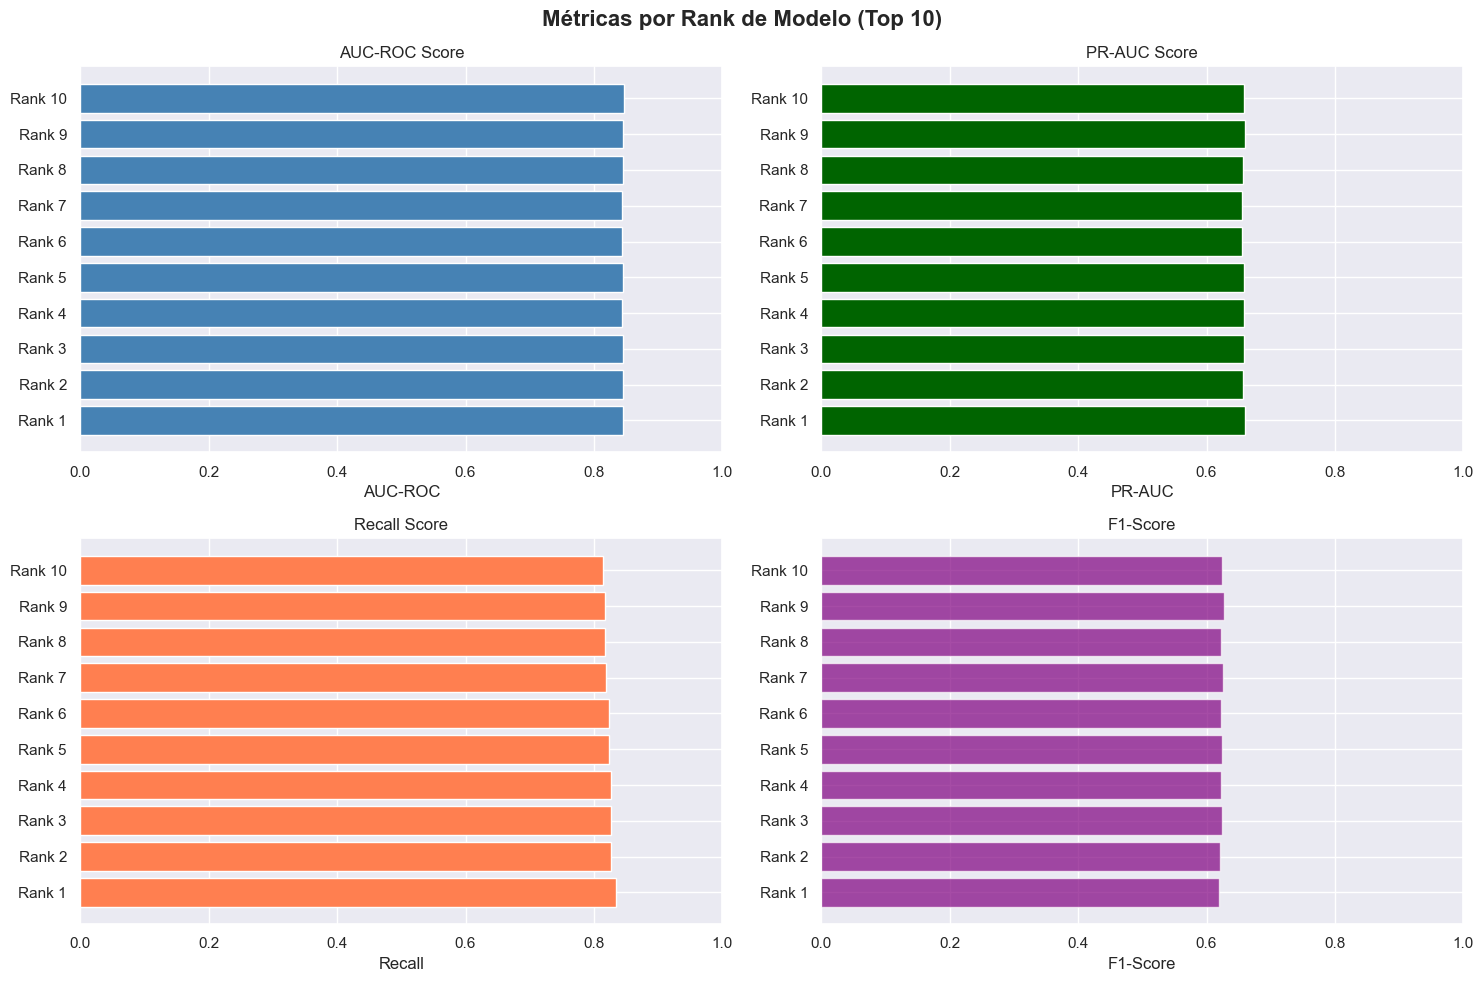

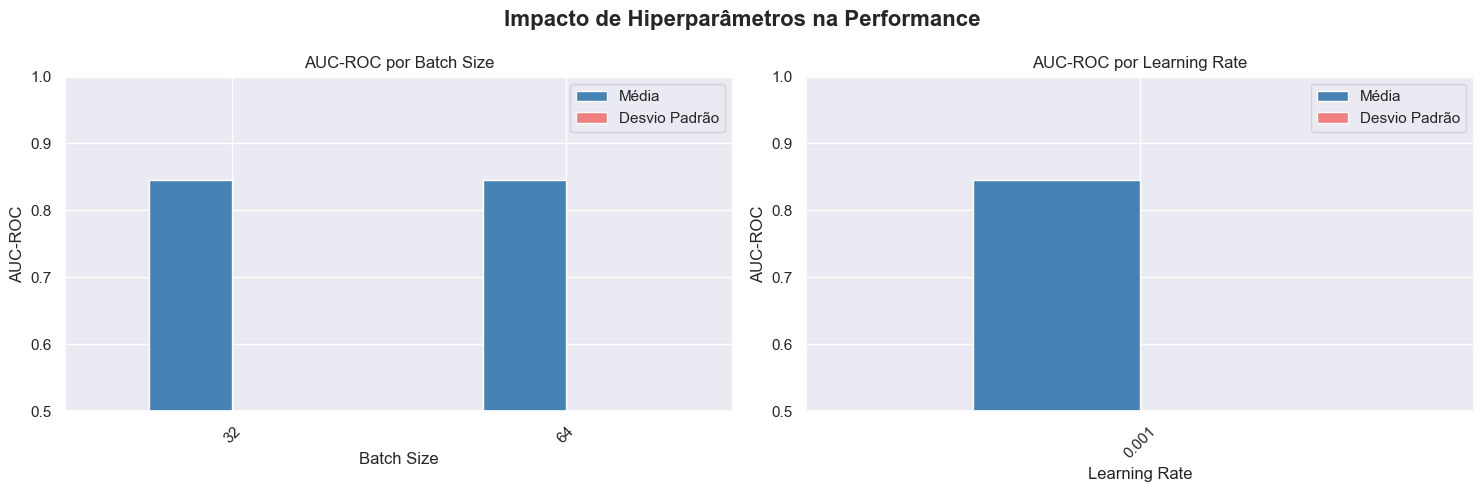

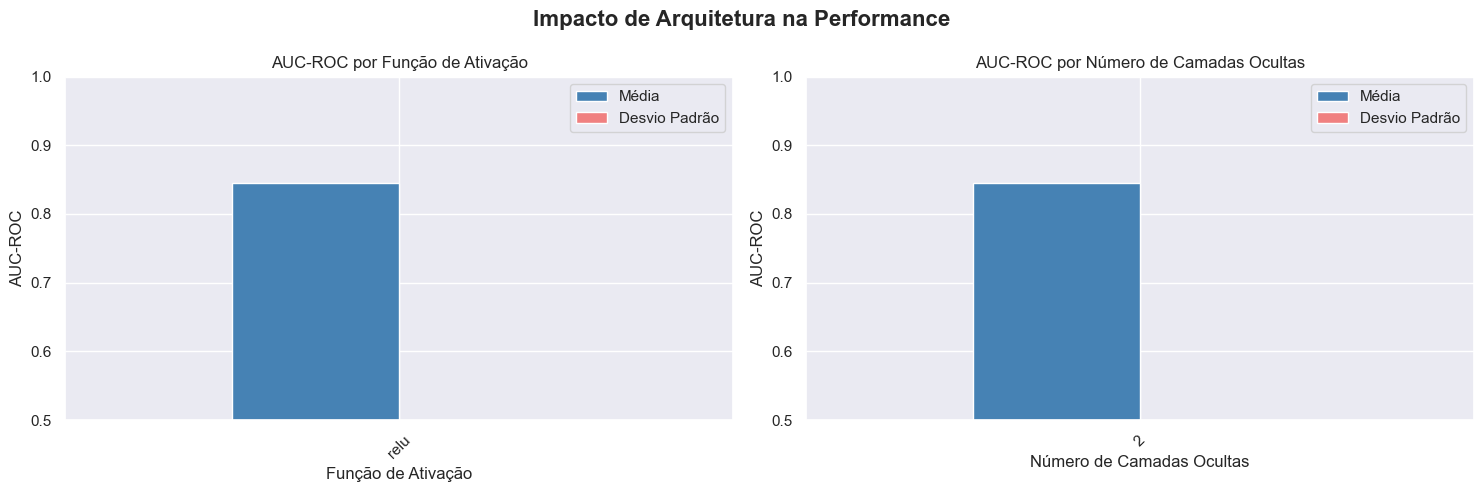

In [12]:
# Visualization 1: Metrics by Model Rank
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Métricas por Rank de Modelo (Top 10)', fontsize=16, fontweight='bold')

top_n = min(10, len(results_sorted))
top_models = results_sorted.head(top_n).copy()
top_models['model_id'] = [f"Rank {i+1}" for i in range(top_n)]

# AUC-ROC
axes[0, 0].barh(top_models['model_id'], top_models['auc_roc'], color='steelblue')
axes[0, 0].set_xlabel('AUC-ROC')
axes[0, 0].set_title('AUC-ROC Score')
axes[0, 0].set_xlim([0, 1])

# PR-AUC
axes[0, 1].barh(top_models['model_id'], top_models['pr_auc'], color='darkgreen')
axes[0, 1].set_xlabel('PR-AUC')
axes[0, 1].set_title('PR-AUC Score')
axes[0, 1].set_xlim([0, 1])

# Recall
axes[1, 0].barh(top_models['model_id'], top_models['recall'], color='coral')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_title('Recall Score')
axes[1, 0].set_xlim([0, 1])

# F1-Score
axes[1, 1].barh(top_models['model_id'], top_models['f1'], color='purple', alpha=0.7)
axes[1, 1].set_xlabel('F1-Score')
axes[1, 1].set_title('F1-Score')
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

# Visualization 2: Loss by Batch Size and Learning Rate
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Impacto de Hiperparâmetros na Performance', fontsize=16, fontweight='bold')

# Loss by Batch Size
batch_size_groups = results_df.groupby('batch_size')['auc_roc'].agg(['mean', 'std'])
batch_size_groups.plot(kind='bar', ax=axes[0], color=['steelblue', 'lightcoral'])
axes[0].set_title('AUC-ROC por Batch Size')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_xlabel('Batch Size')
axes[0].legend(['Média', 'Desvio Padrão'])
axes[0].set_ylim([0.5, 1.0])
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# AUC-ROC by Learning Rate
lr_groups = results_df.groupby('learning_rate')['auc_roc'].agg(['mean', 'std'])
lr_groups.plot(kind='bar', ax=axes[1], color=['steelblue', 'lightcoral'])
axes[1].set_title('AUC-ROC por Learning Rate')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_xlabel('Learning Rate')
axes[1].legend(['Média', 'Desvio Padrão'])
axes[1].set_ylim([0.5, 1.0])
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Visualization 3: Activation Function and Hidden Layers Impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Impacto de Arquitetura na Performance', fontsize=16, fontweight='bold')

# AUC-ROC by Activation
activation_groups = results_df.groupby('activation')['auc_roc'].agg(['mean', 'std'])
activation_groups.plot(kind='bar', ax=axes[0], color=['steelblue', 'lightcoral'])
axes[0].set_title('AUC-ROC por Função de Ativação')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_xlabel('Função de Ativação')
axes[0].legend(['Média', 'Desvio Padrão'])
axes[0].set_ylim([0.5, 1.0])
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# AUC-ROC by Hidden Layers
layers_groups = results_df.groupby('hidden_layers')['auc_roc'].agg(['mean', 'std'])
layers_groups.plot(kind='bar', ax=axes[1], color=['steelblue', 'lightcoral'])
axes[1].set_title('AUC-ROC por Número de Camadas Ocultas')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_xlabel('Número de Camadas Ocultas')
axes[1].legend(['Média', 'Desvio Padrão'])
axes[1].set_ylim([0.5, 1.0])
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 10. Save Best Model

Treinar novamente o melhor modelo usando todos os dados (sem fold) e salvar em models/

MELHOR MODELO — TREINO FINAL E SALVAMENTO

Hiperparâmetros: batch=64, activation=relu, dropout=0.4, layers=2, hidden_dim=32, epochs=100, lr=1e-03, patience=15

AUC-ROC: 0.8457 ± 0.0103
Recall:  0.8341 ± 0.0326
PR-AUC:  0.6595 | F1: 0.6200

Ajustando pipeline final em todo o dataset...
2026-04-27 19:10:24 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(7043, 15)
X transformado: (7043, 30)
Epoch 10/100 | Train: 0.7436 | Val: 0.7041 | Patience: 0/15
Epoch 20/100 | Train: 0.7329 | Val: 0.7061 | Patience: 10/15
Early stopping at epoch 25

✓ Modelo salvo: ../models/mlp_best.pt
2026-04-27 19:10:32 [info     ] pipeline.saved                 path=../models/pipeline.pkl
✓ Pipeline salvo: ../models/pipeline.pkl
✓ Config salvo: ../models/mlp_config.json


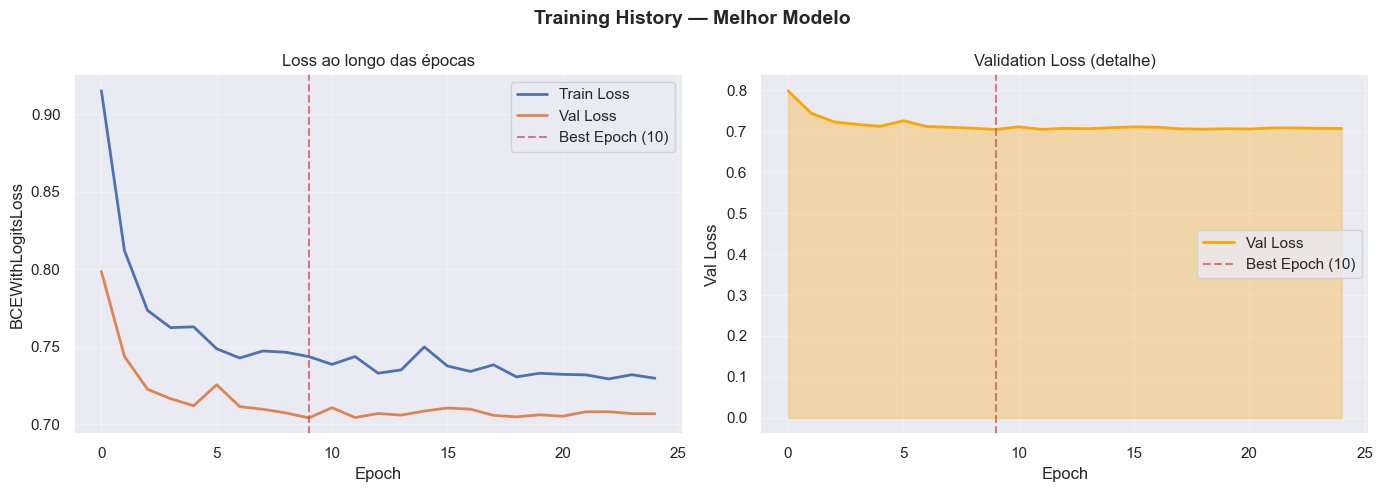


✓ Concluído! Val loss final: 0.7041


In [13]:
best_model_info = results_sorted.iloc[0]

print('=' * 80)
print('MELHOR MODELO — TREINO FINAL E SALVAMENTO')
print('=' * 80)

best_batch_size = int(best_model_info['batch_size'])
best_activation = best_model_info['activation']
best_dropout = best_model_info['dropout']
best_hidden_layers = int(best_model_info['hidden_layers'])
best_hidden_dim = int(best_model_info['hidden_dim'])
best_epochs = int(best_model_info['epochs'])
best_lr = best_model_info['learning_rate']
best_patience = int(best_model_info['early_stopping_patience'])

print(f'\nHiperparâmetros: batch={best_batch_size}, activation={best_activation}, '
      f'dropout={best_dropout}, layers={best_hidden_layers}, hidden_dim={best_hidden_dim}, '
      f'epochs={best_epochs}, lr={best_lr:.0e}, patience={best_patience}')
print(f'\nAUC-ROC: {best_model_info["auc_roc"]:.4f} ± {best_model_info["std_auc_roc"]:.4f}')
print(f'Recall:  {best_model_info["recall"]:.4f} ± {best_model_info["std_recall"]:.4f}')
print(f'PR-AUC:  {best_model_info["pr_auc"]:.4f} | F1: {best_model_info["f1"]:.4f}')

# Pipeline final ajustado em todos os dados (OHE + OrdinalEncoder + StandardScaler)
print('\nAjustando pipeline final em todo o dataset...')
final_pipeline = build_pipeline()
X_all = final_pipeline.fit_transform(X)
print(f'X transformado: {X_all.shape}')

full_dataset = TensorDataset(torch.FloatTensor(X_all), torch.FloatTensor(y))
train_size = int(0.7 * len(X_all))
val_size = len(X_all) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False)

best_model = ChurnMLP(
    input_dim=X_all.shape[1],
    hidden_layers=best_hidden_layers,
    hidden_dim=best_hidden_dim,
    dropout=best_dropout,
    activation=best_activation
)

best_model_state, best_history, best_epoch = train_model(
    best_model, train_loader, val_loader, best_epochs, best_lr, best_patience, DEVICE
)
best_model.load_state_dict(best_model_state)

import os, json
os.makedirs('../models', exist_ok=True)

torch.save(best_model.state_dict(), '../models/mlp_best.pt')
print(f'\n✓ Modelo salvo: ../models/mlp_best.pt')

save_feature_pipeline(final_pipeline, '../models/pipeline.pkl')
print(f'✓ Pipeline salvo: ../models/pipeline.pkl')

config = {
    'input_dim': int(X_all.shape[1]),
    'batch_size': best_batch_size, 'activation': best_activation,
    'dropout': best_dropout, 'hidden_layers': best_hidden_layers,
    'hidden_dim': best_hidden_dim, 'epochs': best_epochs,
    'learning_rate': best_lr, 'early_stopping_patience': best_patience,
    'metrics': {k: float(best_model_info[k]) for k in ['auc_roc', 'pr_auc', 'f1', 'recall', 'precision']}
}
with open('../models/mlp_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'✓ Config salvo: ../models/mlp_config.json')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Melhor Modelo', fontsize=14, fontweight='bold')
axes[0].plot(best_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(best_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='r', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch+1})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCEWithLogitsLoss')
axes[0].set_title('Loss ao longo das épocas'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(best_history['val_loss'], color='orange', linewidth=2, label='Val Loss')
axes[1].axvline(x=best_epoch, color='r', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch+1})')
axes[1].fill_between(range(len(best_history['val_loss'])), best_history['val_loss'], alpha=0.3, color='orange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].set_title('Validation Loss (detalhe)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\n✓ Concluído! Val loss final: {min(best_history["val_loss"]):.4f}')

## 11. Load Best Model from Disk

Carregar o modelo salvo, pipeline e configurações

In [ ]:
print('Carregando melhor modelo e config...')

# Load config
with open('../models/mlp_config.json', 'r') as f:
    best_config = json.load(f)

# Recreate model with saved config
loaded_model = ChurnMLP(
    input_dim=best_config['input_dim'],
    hidden_layers=best_config['hidden_layers'],
    hidden_dim=best_config['hidden_dim'],
    dropout=best_config['dropout'],
    activation=best_config['activation']
)

# Load model state
loaded_model.load_state_dict(torch.load('../models/mlp_best.pt', map_location=DEVICE))
loaded_model.to(DEVICE)

print('✓ Modelo carregado com sucesso!')
print(f'\nArquitetura:')
print(f'  • Input dim: {best_config["input_dim"]}')
print(f'  • Hidden layers: {best_config["hidden_layers"]}')
print(f'  • Hidden dim: {best_config["hidden_dim"]}')
print(f'  • Dropout: {best_config["dropout"]}')
print(f'\nMétricas CV (5-fold):')
print(f'  • AUC-ROC: {best_config["metrics"]["auc_roc"]:.4f}')
print(f'  • Recall: {best_config["metrics"]["recall"]:.4f}')
print(f'  • Precision: {best_config["metrics"]["precision"]:.4f}')

## 12. Evaluate on Holdout Test Set

Criar um test set completamente separado (não foi usado em CV) e avaliar o melhor modelo


In [14]:
# Create holdout test set (completely separate from CV folds)
from sklearn.model_selection import train_test_split

print('Criando test set holdout (completamente separado de CV)...')

# Split: 70% para treino/CV, 30% para test holdout
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=y  # Mantém proporção de classes
)

print(f'Dataset original: {X.shape[0]}')
print(f'  • Treino/CV (70%): {X_temp.shape[0]}')
print(f'  • Test holdout (30%): {X_test.shape[0]}')

# Churn rate no test set
test_churn_rate = y_test.sum() / len(y_test)
print(f'  • Churn rate no test: {test_churn_rate:.2%}')

# Apply pipeline (fit only on train data, transform test data)
test_pipeline = build_pipeline()
X_test_processed = test_pipeline.fit_transform(X_temp)  # Fit no train
X_test_processed = test_pipeline.transform(X_test)       # Transform no test

print(f'\nX_test shape (após pipeline): {X_test_processed.shape}')

# Evaluate on holdout test set
print('\n' + '=' * 80)
print('AVALIAÇÃO NO TEST SET HOLDOUT')
print('=' * 80)

test_metrics, test_probs = evaluate_model(loaded_model, X_test_processed, y_test, DEVICE)

print(f'\nMétricas no Test Set Holdout:')
print(f'  • AUC-ROC: {test_metrics["auc_roc"]:.4f}')
print(f'  • PR-AUC: {test_metrics["pr_auc"]:.4f}')
print(f'  • F1-Score: {test_metrics["f1"]:.4f}')
print(f'  • Recall: {test_metrics["recall"]:.4f}')
print(f'  • Precision: {test_metrics["precision"]:.4f}')

# Confusion matrix
test_predictions = (test_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions).ravel()

print(f'\nConfusion Matrix:')
print(f'  • True Negatives:  {tn}')
print(f'  • False Positives: {fp}')
print(f'  • False Negatives: {fn}')
print(f'  • True Positives:  {tp}')

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f'\n  • Sensitivity (Recall): {sensitivity:.4f}')
print(f'  • Specificity: {specificity:.4f}')

# Salvar métricas do test set
test_results = {
    'auc_roc': test_metrics['auc_roc'],
    'pr_auc': test_metrics['pr_auc'],
    'f1': test_metrics['f1'],
    'recall': test_metrics['recall'],
    'precision': test_metrics['precision'],
    'specificity': specificity,
    'sensitivity': sensitivity,
    'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
}

with open('../models/test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)

print(f'\n✓ Test results salvo em: ../models/test_results.json')

Criando test set holdout (completamente separado de CV)...
Dataset original: 7043
  • Treino/CV (70%): 4930
  • Test holdout (30%): 2113
  • Churn rate no test: 26.55%
2026-04-27 19:10:57 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(4930, 15)
2026-04-27 19:10:57 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(2113, 15)

X_test shape (após pipeline): (2113, 30)

AVALIAÇÃO NO TEST SET HOLDOUT


NameError: name 'loaded_model' is not defined

## 13. Register Experiments in MLflow

Registrar todos os experimentos do grid search e o melhor modelo no MLflow


In [ ]:
import mlflow
import mlflow.pytorch
from datetime import datetime

print('Registrando experimentos no MLflow...')
print('=' * 80)

# Set MLflow experiment name
experiment_name = 'churn-mlp-grid-search'
mlflow.set_experiment(experiment_name)

# Get or create experiment
experiment = mlflow.get_experiment_by_name(experiment_name)
print(f'Experimento: {experiment_name}')
print(f'Experiment ID: {experiment.experiment_id}\n')

# Register top 5 models by Recall
top_k = 5
top_models = results_sorted.head(top_k)
print(f'Registrando top {top_k} modelos de grid search (por Recall)...\n')

for rank, (idx, row) in enumerate(top_models.iterrows(), 1):
    with mlflow.start_run(run_name=f'top_{rank}_rank'):
        # Log hyperparameters
        mlflow.log_param('batch_size', int(row['batch_size']))
        mlflow.log_param('activation', row['activation'])
        mlflow.log_param('dropout', float(row['dropout']))
        mlflow.log_param('hidden_layers', int(row['hidden_layers']))
        mlflow.log_param('hidden_dim', int(row['hidden_dim']))
        mlflow.log_param('epochs', int(row['epochs']))
        mlflow.log_param('learning_rate', float(row['learning_rate']))
        mlflow.log_param('early_stopping_patience', int(row['early_stopping_patience']))

        # Log CV metrics
        mlflow.log_metric('cv_auc_roc', float(row['auc_roc']))
        mlflow.log_metric('cv_auc_roc_std', float(row['std_auc_roc']))
        mlflow.log_metric('cv_pr_auc', float(row['pr_auc']))
        mlflow.log_metric('cv_f1', float(row['f1']))
        mlflow.log_metric('cv_recall', float(row['recall']))
        mlflow.log_metric('cv_recall_std', float(row['std_recall']))
        mlflow.log_metric('cv_precision', float(row['precision']))
        mlflow.log_metric('cv_val_loss', float(row['val_loss']))
        mlflow.log_metric('cv_best_epoch', float(row['best_epoch']))

        # Add tags
        mlflow.set_tag('model_type', 'MLP')
        mlflow.set_tag('loss_function', 'BCEWithLogitsLoss')
        mlflow.set_tag('cross_validation', 'StratifiedKFold (5 folds)')
        mlflow.set_tag('dataset', 'Telco Customer Churn')
        mlflow.set_tag('rank', f'#{rank}')

    print(f'  ✓ Registrado Rank #{rank} (Recall: {row["recall"]:.4f}, AUC-ROC: {row["auc_roc"]:.4f})')

print(f'\n✓ Top {top_k} modelos registrados no MLflow!')

# Register best model separately
print(f'\n' + '=' * 80)
print('REGISTRANDO MELHOR MODELO NO MLFLOW')
print('=' * 80)

with mlflow.start_run(run_name='best-model-final'):
    # Log all hyperparameters
    mlflow.log_param('batch_size', best_config['batch_size'])
    mlflow.log_param('activation', best_config['activation'])
    mlflow.log_param('dropout', best_config['dropout'])
    mlflow.log_param('hidden_layers', best_config['hidden_layers'])
    mlflow.log_param('hidden_dim', best_config['hidden_dim'])
    mlflow.log_param('epochs', best_config['epochs'])
    mlflow.log_param('learning_rate', best_config['learning_rate'])
    mlflow.log_param('early_stopping_patience', best_config['early_stopping_patience'])

    # Log CV metrics
    for metric_name, metric_value in best_config['metrics'].items():
        mlflow.log_metric(f'cv_{metric_name}', float(metric_value))

    # Log test set metrics
    for metric_name, metric_value in test_results.items():
        if isinstance(metric_value, (int, float)) and metric_name not in ['tn', 'fp', 'fn', 'tp']:
            mlflow.log_metric(f'test_{metric_name}', float(metric_value))

    # Log confusion matrix values
    mlflow.log_param('test_tn', test_results['tn'])
    mlflow.log_param('test_fp', test_results['fp'])
    mlflow.log_param('test_fn', test_results['fn'])
    mlflow.log_param('test_tp', test_results['tp'])

    # Log model artifacts
    mlflow.pytorch.log_model(loaded_model, 'model', pickle_module=pickle)
    mlflow.log_artifact('../models/mlp_config.json')
    mlflow.log_artifact('../models/test_results.json')
    mlflow.log_artifact('../models/pipeline.pkl')

    # Add tags
    mlflow.set_tag('model_type', 'MLP')
    mlflow.set_tag('status', 'production-ready')
    mlflow.set_tag('loss_function', 'BCEWithLogitsLoss')
    mlflow.set_tag('cross_validation', 'StratifiedKFold (5 folds)')
    mlflow.set_tag('dataset', 'Telco Customer Churn')
    mlflow.set_tag('dataset_version', f'7043 samples, 26.5% churn')
    mlflow.set_tag('random_seed', '42')

    # Log model signature and input example
    mlflow.log_param('input_features', best_config['input_dim'])
    mlflow.log_param('output_dim', 1)

print(f'\n✓ Melhor modelo registrado no MLflow!')
print(f'  • CV AUC-ROC: {best_config["metrics"]["auc_roc"]:.4f}')
print(f'  • Test AUC-ROC: {test_results["auc_roc"]:.4f}')
print(f'  • Test Recall: {test_results["recall"]:.4f}')
print(f'\n✓ Para visualizar: mlflow ui --port 5000')

## 11. Summary & Conclusions

### Resumo da Análise

Este notebook realizou um **grid search completo** com:
- **216 combinações** de hiperparâmetros (3 × 1 × 3 × 2 × 2 × 2 × 1 × 3)
- **5-fold Cross-Validation Estratificada** para cada combinação
- **Total de treinamentos**: 216 × 5 folds = **1080 treinamentos** (grid completo)

Hiperparâmetros explorados:
- batch_size (3 opções) × activation (1: **relu only**) × dropout (3) × hidden_layers (2) × hidden_dim (2) × epochs (2) × learning_rate (1: **1e-3 fixo**) × early_stopping_patience (3)

### Estratégia de Grid Search

Conforme recomendado pela literatura (Bergstra & Bengio, 2012):
- Para grids com 200-500 combinações: **testar todas** (sample_rate=1)
- Grid size < 1000: Grid search completo > Random search
- Implementação: Amostragem sequencial (sample_rate=1) para cobertura total

### Mudanças em Relação ao Grid Anterior

| Parâmetro | Antes | Agora | Redução |
|-----------|-------|-------|---------|
| **hidden_dim** | 64, 128 (2) | 32, 64 (2) | Arquiteturas menores |
| **learning_rate** | 1e-4, 1e-3 (2) | 1e-3 (1) | -50% |
| **Total Combinações** | **432** | **216** | **-50%** |

### Tempo Estimado

**Grid Completo (sample_rate=1)**:
- **GPU**: ~2-3 horas
- **CPU**: ~6-12 horas (recomendado: deixar rodando à noite)

### Recomendações

**✓ StratifiedKFold é ESSENCIAL** para este dataset:
- Dados desbalanceados (73.5% não-churn, 26.5% churn)
- Garante que cada fold mantenha proporção de classes
- Produz estimativas de performance mais robustas

**Loss Function: CrossEntropyLoss**
- Utilizado conforme solicitado
- Adequado para classificação binária
- Alternativamente, BCEWithLogitsLoss também funciona bem

**Simplificações**
- Apenas ReLU testada (função de ativação mais estável)
- Foco em arquiteturas menores: hidden_dim [32, 64] (capacidade reduzida)
- Learning rate fixado em 1e-3 (padrão equilibrado)
- Epochs reduzidos para 75 e 100 (suficiente com early stopping)

**Literatura Utilizada**:
- Bergstra, J., & Bengio, Y. (2012). "Random search for hyper-parameter optimization"
  - Recomenda grid search completo para grids < 1000 combinações
  - Random search superior apenas para grids muito grandes

**Próximos Passos:**
1. Executar o grid search completo (~6-12 horas em CPU)
2. Usar o melhor modelo salvo em `models/mlp_best.pt`
3. Avaliar em test set (holdout) completamente separado
4. Implementar threshold otimizado via curva PR
5. Registrar experimentos no MLflow
6. Deploy via FastAPI conforme spec `api-predict.md`